In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

df = pd.read_csv('../data/pjme_clean.csv', index_col='datetime', parse_dates=True)
df_daily = df.resample('D').mean()

print(f"Shape: {df_daily.shape}")
df_daily.head()

PyTorch version: 2.10.0
Device: cpu
Shape: (6059, 1)


,energy_mw
datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


In [2]:
split_date = '2018-01-01'
train = df_daily[df_daily.index < split_date]
test = df_daily[df_daily.index >= split_date]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

print(f"Train: {train_scaled.shape}")
print(f"Test: {test_scaled.shape}")

Train: (5844, 1)
Test: (215, 1)


In [3]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

X_train_t = torch.FloatTensor(X_train).unsqueeze(-1).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).unsqueeze(-1).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"X_train: {X_train_t.shape} | y_train: {y_train_t.shape}")
print(f"X_test: {X_test_t.shape} | y_test: {y_test_t.shape}")

X_train: torch.Size([5814, 30, 1]) | y_train: torch.Size([5814])
X_test: torch.Size([185, 30, 1]) | y_test: torch.Size([185])


In [4]:
class EnergyLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(EnergyLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        output = self.fc(last_hidden)
        return output.squeeze()

model = EnergyLSTM().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

EnergyLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 51,489


In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100
PATIENCE = 10

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

val_size = int(len(X_train_t) * 0.1)
X_val = X_train_t[-val_size:]
y_val = y_train_t[-val_size:]

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch 10/100 | Train Loss: 0.005636 | Val Loss: 0.006572
Epoch 20/100 | Train Loss: 0.004792 | Val Loss: 0.005890
Epoch 30/100 | Train Loss: 0.004510 | Val Loss: 0.005814
Epoch 40/100 | Train Loss: 0.004450 | Val Loss: 0.005878

Early stopping at epoch 43

Best validation loss: 0.005160


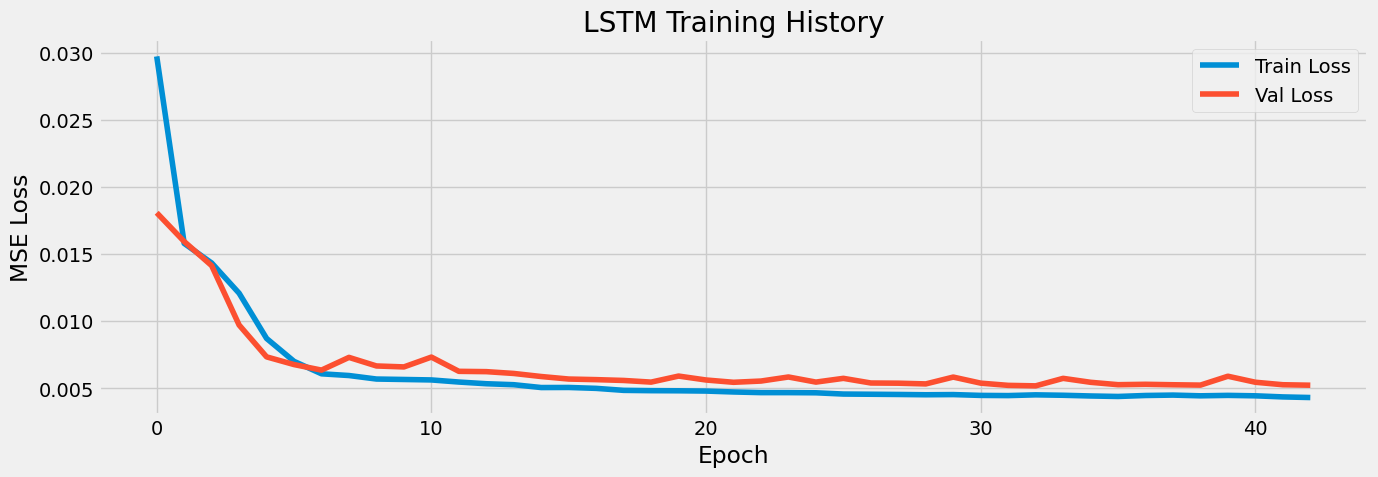

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Val Loss')
ax.set_title('LSTM Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()

y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE:  1484.17 MW
RMSE: 1951.70 MW
MAPE: 4.75%


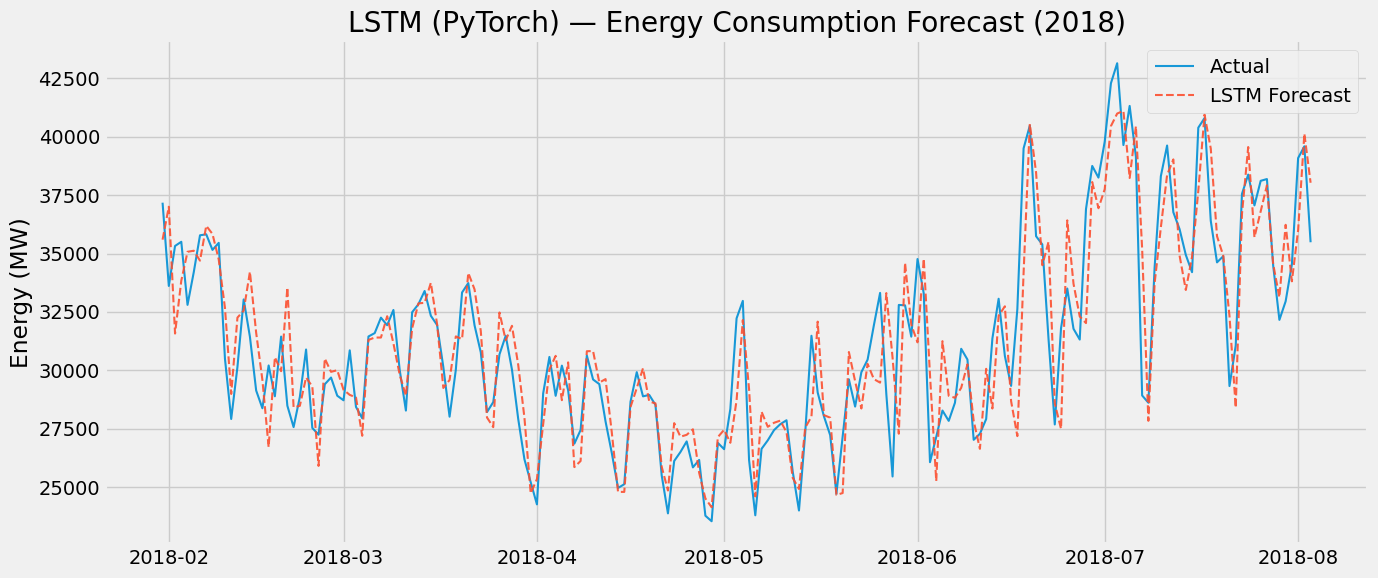

In [8]:
test_dates = test.index[WINDOW_SIZE:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, y_true, label='Actual', alpha=0.9, linewidth=1.5)
ax.plot(test_dates, y_pred, label='LSTM Forecast', linestyle='--', alpha=0.9, linewidth=1.5)
ax.set_title('LSTM (PyTorch) — Energy Consumption Forecast (2018)')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
results_df = pd.DataFrame({
    'actual': y_true,
    'predicted': y_pred
}, index=test_dates)
results_df.to_csv('../results/lstm_results.csv')

metrics = {
    'model': 'LSTM (PyTorch)',
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape
}
pd.DataFrame([metrics]).to_csv('../results/lstm_metrics.csv', index=False)

torch.save(model.state_dict(), '../models/lstm_model.pth')

print("Saved results & model")

Saved results & model
